In [1]:
#!pip install segmentation-models-pytorch
#!pip install -U git+https://github.com/albumentations-team/albumentations
#!pip install --upgrade opencv-contrib-python

In [2]:
!nvidia-smi

Wed Jun 19 20:22:49 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
| 37%   59C    P3             122W / 370W |      1MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Dataset

In [3]:
#!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

In [4]:
#import sys
#sys.path.append('Human-Segmentation-Dataset-master')

In [5]:
import torch 
import cv2

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

## Task : 2 Setup Configurations


In [6]:
#CSV_FILE = 'DataFN.csv'
#CSV_testFILE = 'DataTestFN.csv'
#CSV_FILE = 'DataFN_3Ch_FT1T2.csv'
#CSV_testFILE = 'DatatestFN_3Ch_FT1T2.csv'
#CSV_FILE = 'DataFN_3Ch_Flair5avg.csv'
#CSV_testFILE = 'DatatestFN_3Ch_Flair5avg.csv'
#CSV_FILE = 'Data2FN_3Ch_Flair.csv'
#CSV_testFILE = 'Datatest2FN_3Ch_Flair.csv'

CSV_FILE = 'DataFN_mat_MultiCh_15.csv'
CSV_testFILE = 'DatatestFN_mat_MultiCh_15.csv'

#CSV_testFILE0 = 'DataTestFN0.csv'
#CSV_testFILE100 = 'DataTestFN100.csv'
DATA_DIR = ''

DEVICE = 'cuda'

EPOCHS = 2000
IMAGE_SIZE = 256
BATCH_SIZE = 80
Patience = 30
ENCODER = 'timm-efficientnet-b1'
WEIGHTS = 'imagenet'

In [7]:
df = pd.read_csv(CSV_FILE)
test_df = pd.read_csv(CSV_testFILE)
#test_df0 = pd.read_csv(CSV_testFILE0)
#test_df100 = pd.read_csv(CSV_testFILE100)
df.head()

,images,masks
0,Dataset/train/MultiCh_15/P1_T1_45.mat,Dataset/train/MultiCh_Mask_15/P1_T1_45.mat
1,Dataset/train/MultiCh_15/P1_T1_46.mat,Dataset/train/MultiCh_Mask_15/P1_T1_46.mat
2,Dataset/train/MultiCh_15/P1_T1_47.mat,Dataset/train/MultiCh_Mask_15/P1_T1_47.mat
3,Dataset/train/MultiCh_15/P1_T1_48.mat,Dataset/train/MultiCh_Mask_15/P1_T1_48.mat
4,Dataset/train/MultiCh_15/P1_T1_49.mat,Dataset/train/MultiCh_Mask_15/P1_T1_49.mat


In [8]:
from scipy.io import loadmat

row = df.iloc[500]

image_path = row.images
mask_path = row.masks


# Load the .mat file
mat = loadmat(image_path)
matrix = mat['im']
image = matrix[:,:,0:3]
mat = loadmat(mask_path)
matrix = mat['imMask']
mask = matrix[:,:,0:3]
#image = cv2.imread(image_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)



(182, 182, 3)


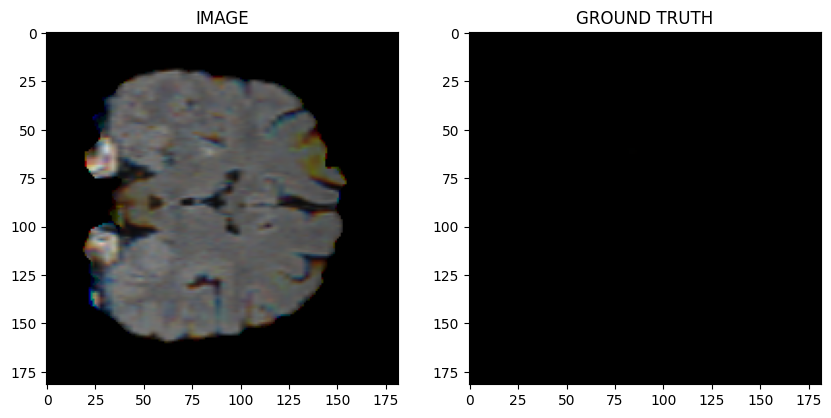

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

#image = np.transpose(image ,(2,0,1)).astype(np.float32)
#mask = np.transpose(mask ,(2,0,1)).astype(np.float32)

print(image.shape)
ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask, cmap = 'gray')

In [10]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

## Task 3 : Augmentation Functions


In [11]:
import albumentations as A

def get_train_augs():
   return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        #A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.0, rotate_limit=0, p=0.5),
        #A.RandomBrightnessContrast(p=0.5),
        #A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
   ])
def get_valid_augs():
   return A.Compose([
   ])

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.9 (you have 1.4.8). Upgrade using: pip install --upgrade albumentations


## Task 4 : Create Custom Dataset


In [12]:
from torch.utils.data import Dataset

nCh = 15

class SegmentationDataset(Dataset):
  def __init__(self,df, augmentations):
    self.df=df
    self.augmentations = augmentations 
  def __len__(self):
    return len(self.df)
  def __getitem__(self ,idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    #print('image path: ', image_path)
    #print('mask path: ', mask_path)
    mat = loadmat(image_path)
    matrix = mat['im']
    image1 = matrix[:,:,0:3]
    image2 = matrix[:,:,3:6]
    image3 = matrix[:,:,6:9]
    image4 = matrix[:,:,9:12]
    image5 = matrix[:,:,12:15]
    image = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
    image1 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    image = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
    image2 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    image = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)
    image3 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    image = cv2.cvtColor(image4, cv2.COLOR_BGR2RGB)
    image4 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    image = cv2.cvtColor(image5, cv2.COLOR_BGR2RGB)
    image5 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)

    mat = loadmat(mask_path)
    matrix = mat['imMask']
    mask1 = matrix[:,:,0:3]
    mask2 = matrix[:,:,3:6]
    mask3 = matrix[:,:,6:9]
    mask4 = matrix[:,:,9:12]
    mask5 = matrix[:,:,12:15]
    image = cv2.cvtColor(mask1, cv2.COLOR_BGR2RGB)
    mask1 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask1 =np.expand_dims(image ,axis=-1)
    image = cv2.cvtColor(mask2, cv2.COLOR_BGR2RGB)
    mask2 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask2 =np.expand_dims(image ,axis=-1)
    image = cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB)
    mask3 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask3 =np.expand_dims(image ,axis=-1)
    image = cv2.cvtColor(mask4, cv2.COLOR_BGR2RGB)
    mask4 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask4 =np.expand_dims(image ,axis=-1)
    image = cv2.cvtColor(mask5, cv2.COLOR_BGR2RGB)
    mask5 = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask5 =np.expand_dims(image ,axis=-1)

    
    #mask = cv2.imread(mask_path , cv2.IMREAD_GRAYSCALE) #(h,w,c)
    #print('mask 0 size: ', mask.shape)
    #mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    #mask =np.expand_dims(mask ,axis=-1)
    #print('image size: ', image1.shape)
    #print('mask size: ', mask1.shape)

    #if self.augmentations :
    #  data =self.augmentations(image = image , mask = mask)
    #  image = data['image']
    #  mask = data ['mask']

    image = np.zeros((IMAGE_SIZE, IMAGE_SIZE, nCh))
    image[:,:,0:3] = image1
    image[:,:,3:6] = image2
    image[:,:,6:9] = image3
    image[:,:,9:12] = image4
    image[:,:,12:15] = image5
    mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE, nCh))
    mask[:,:,0:3] = mask1
    mask[:,:,3:6] = mask2
    mask[:,:,6:9] = mask3
    mask[:,:,9:12] = mask4
    mask[:,:,12:15] = mask5
    #(h,w,c) -> (c,h,w)
    image = np.transpose(image ,(2,0,1)).astype(np.float32)
    mask = np.transpose(mask ,(2,0,1)).astype(np.float32)

    #print('image sum 1 : ', image.max())
    image = torch.Tensor(image)/255.0
    #print('image sum 2 : ', image.max())
    #print('mask sum 1 : ', mask.max())
    mask = torch.round(torch.Tensor(mask)/1.0)
    #print('mask sum 2 : ', mask.max())
    #print('image size: ', image.shape)
    #print('mask size: ', mask.shape)

    return image,mask

In [13]:
trainset = SegmentationDataset(train_df,get_train_augs())
validset = SegmentationDataset(valid_df,get_valid_augs())
testset = SegmentationDataset(test_df,get_valid_augs())
#testset0 = SegmentationDataset(test_df0,get_valid_augs())
#testset100 = SegmentationDataset(test_df100,get_valid_augs())


In [14]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 7888
Size of Validset : 1972


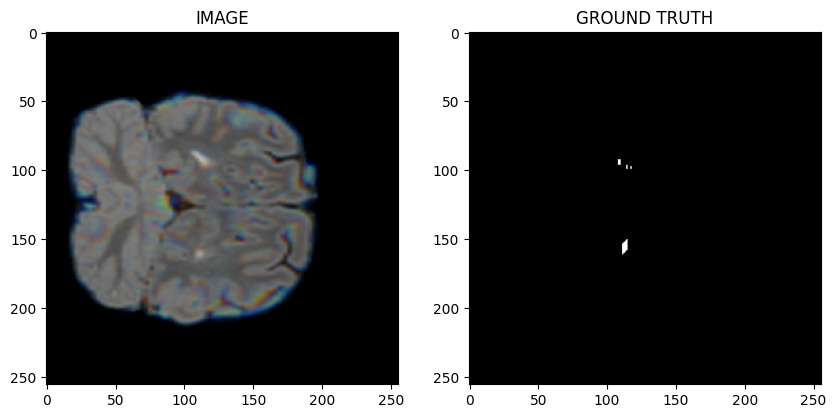

In [15]:
idx = 100
image,mask = trainset[idx]
img=image[0:3,:,:]
msk=mask[7,:,:]
msk =torch.Tensor(np.expand_dims(msk ,axis=0))

#print('image size: ', img.shape)
#print('mask size: ', msk.shape)
#print('mask sum : ', mask.sum())

helper.show_image(img,msk)


## Task 5 : Load dataset into batches


In [16]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset , batch_size =BATCH_SIZE , shuffle =True )
validloader = DataLoader(validset , batch_size =BATCH_SIZE  )

In [17]:
print(f"total no,of batches in trainloader: {len(trainloader)}")
print(f"total no,of batches in validloader: {len(validloader)}")

total no,of batches in trainloader: 99
total no,of batches in validloader: 25


In [18]:
for image , mask in trainloader:
  break
print (f'One batch image shape: {image.shape}')
print (f'One batch image shape: {mask.shape}')

One batch image shape: torch.Size([80, 15, 256, 256])
One batch image shape: torch.Size([80, 15, 256, 256])



## Task 6 : Create Segmentation Model


In [19]:
#! pip install segmentation_models_pytorch

In [20]:
from torch import nn 
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [21]:

class BinaryIntersection(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        return  intersection

class BinaryUnion(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        return  union
        
class BinarySum(torch.nn.Module):
    def forward(self, pred, target):
        sumAB = pred.sum() + target.sum()
        return  sumAB
        

A , B = 1 , 1
class BinaryJaccardLoss(torch.nn.Module):
    def forward(self, pred, target):
       if (pred.sum() ==0) and (target.sum() == 0):
           jaccard_index = 1
       else:        
           #print(f'pred size = {pred.shape} ,  target size = {target.shape}')
           intersection = (pred * target).sum() + A
           union = pred.sum() + target.sum() - intersection + B
           jaccard_index = 1 - intersection / (union)
       return  jaccard_index


In [22]:
class SegmentationModel (nn.Module):

  def __init__(self):
    super (SegmentationModel , self).__init__()
    
    self.arc = smp.Unet(
        encoder_name= ENCODER ,
        encoder_weights=  WEIGHTS ,
        in_channels= 15 ,
        classes=  15 ,
        activation = None
    )

  def forward (self ,images ,masks = None):
    result = self.arc(images)
    result = torch.sigmoid (result)
      
    if masks != None :
      #print(f'max of result = {result.max()}  , max of mask = {masks.max()}')
      #loss1 = DiceLoss(mode='binary')(result , masks)
      #loss1 = nn.BCEWithLogitsLoss()(result , masks)
      #loss1 = nn.CrossEntropyLoss()(result , masks)
      loss1 = BinaryJaccardLoss()(result , masks)
      #print('loss: ', loss1)
      return result , loss1
    return result

In [23]:
model = SegmentationModel()
model.to(DEVICE)

SegmentationModel(
  (arc): Unet(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(15, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (gate): Sigmoid()
            )
          

In [24]:
from torchsummary import summary
summary(model, (15, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]           4,320
          Identity-2         [-1, 32, 128, 128]               0
             Swish-3         [-1, 32, 128, 128]               0
    BatchNormAct2d-4         [-1, 32, 128, 128]              64
            Conv2d-5         [-1, 32, 128, 128]             288
          Identity-6         [-1, 32, 128, 128]               0
             Swish-7         [-1, 32, 128, 128]               0
    BatchNormAct2d-8         [-1, 32, 128, 128]              64
            Conv2d-9              [-1, 8, 1, 1]             264
            Swish-10              [-1, 8, 1, 1]               0
           Conv2d-11             [-1, 32, 1, 1]             288
          Sigmoid-12             [-1, 32, 1, 1]               0
    SqueezeExcite-13         [-1, 32, 128, 128]               0
           Conv2d-14         [-1, 16, 1


## Task 7 : Create Train and Validation Function


In [25]:
def train_fn (data_loader , model , optimizer):
  model.train()
  total_loss =0.0

  for images, masks in tqdm(data_loader) :

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits , loss = model(images ,masks)
    loss.backward()
    optimizer.step()

    total_loss +=loss.item()

    return total_loss / len(data_loader)

In [26]:
def eval_fn (data_loader , model ):

  model.eval()
  total_loss =0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader) :

      images = images.to(DEVICE)
      masks = masks.to(DEVICE)

      logits , loss = model(images ,masks)

      total_loss +=loss.item()

  return total_loss / len(data_loader)


## Task 8 : Train Model


In [27]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}  and the min vall loss = {-self.best_score}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        #torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=Patience, verbose=True)


In [28]:
import GPUtil
GPUtil.showUtilization()


| ID | GPU | MEM |
------------------
|  0 |  5% |  4% |


In [29]:
import GPUtil
from torch.optim.lr_scheduler import ReduceLROnPlateau

LR = 0.002
LR_Reduce_freq = 20
Valid_period = 20

optimizer = torch.optim.Adam(model.parameters(),lr= LR)
#scheduler = ReduceLROnPlateau(optimizer, 'min')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

best_valid_loss = np.Inf
TrainLoss = [1]*EPOCHS
ValidLoss = [1]*EPOCHS
LearnRate = [1]*EPOCHS
valid_loss = 1
for i in range(EPOCHS):
    GPUtil.showUtilization()
    LearnRate[i] = scheduler.get_last_lr()[0]
    print('Learning rate = ', LearnRate[i])
    train_loss = train_fn(trainloader , model , optimizer)
    #print('train_loss = ', train_loss)
    if ((i+1) % Valid_period == 0):
        valid_loss = eval_fn(validloader , model  )
    #valid_loss = 0.1
    #print('valid_loss = ', valid_loss)
    TrainLoss[i] = train_loss
    ValidLoss[i] = valid_loss
    
    if valid_loss< best_valid_loss :
        torch.save(model.state_dict(), 'bestModel.pt')
        print ("SAVED")
        best_valid_loss = valid_loss
    print(f"Epoch : {i+1} train_loss :{train_loss} valid_loss :{valid_loss}" )
    
    if ((i+1) % LR_Reduce_freq == 0) and (valid_loss<0.9):
        scheduler.step()
    #if valid_loss<0.5:
    #    LR_Reduce_freq = 10
    if LearnRate[i]<0.0001:
        LR_Reduce_freq = 100
    
    if ((i+1) % Valid_period == 0):
        early_stopping(valid_loss, model)

    #if i==300:
    #    torch.save(model.state_dict(), 'Model_ep_300.pt')
    #if i==400:
    #    torch.save(model.state_dict(), 'Model_ep_400.pt')
    #if i==500:
    #    torch.save(model.state_dict(), 'Model_ep_500.pt')
        
    if early_stopping.early_stop:
        print("Early stopping")
        break
    

| ID | GPU | MEM |
------------------
|  0 |  5% |  4% |
Learning rate =  0.002


  0%|          | 0/99 [00:00<?, ?it/s]/home/jupyter-ziaratban_stu4/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
/home/jupyter-ziaratban_stu4/.local/lib/python3.10/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|          | 0/99 [00:01<?, ?it/s]


SAVED
Epoch : 1 train_loss :0.010072351104081279 valid_loss :1
| ID | GPU | MEM |
------------------
|  0 | 93% | 79% |
Learning rate =  0.002


  0%|          | 0/99 [00:01<?, ?it/s]


Epoch : 2 train_loss :0.010072136166119816 valid_loss :1
| ID | GPU  | MEM |
-------------------
|  0 | 100% | 97% |
Learning rate =  0.002


...

Epoch : 1998 train_loss :0.002691414019074103 valid_loss :0.30218652725219725
| ID | GPU  | MEM |
-------------------
|  0 | 100% | 97% |
Learning rate =  2.3945030365124063e-05


  0%|          | 0/99 [00:01<?, ?it/s]


Epoch : 1999 train_loss :0.003114024798075358 valid_loss :0.30218652725219725
| ID | GPU | MEM |
------------------
|  0 | 96% | 97% |
Learning rate =  2.3945030365124063e-05


100%|██████████| 25/25 [00:22<00:00,  1.10it/s]

Epoch : 2000 train_loss :0.0030626720852322048 valid_loss :0.3025806999206543
EarlyStopping counter: 1 out of 30  and the min vall loss = 0.30218652725219725


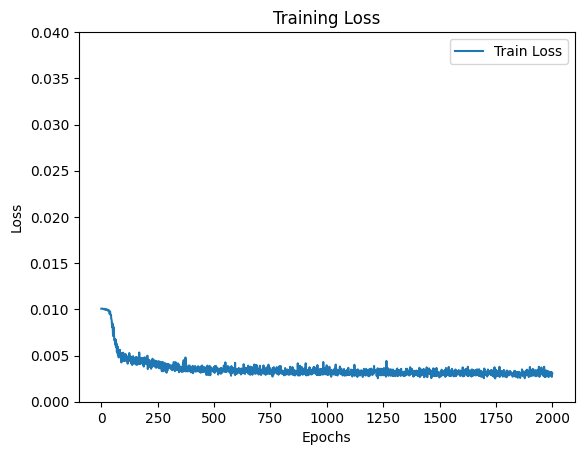

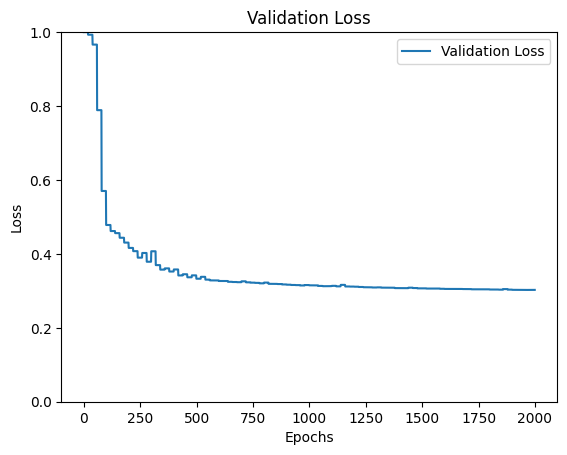

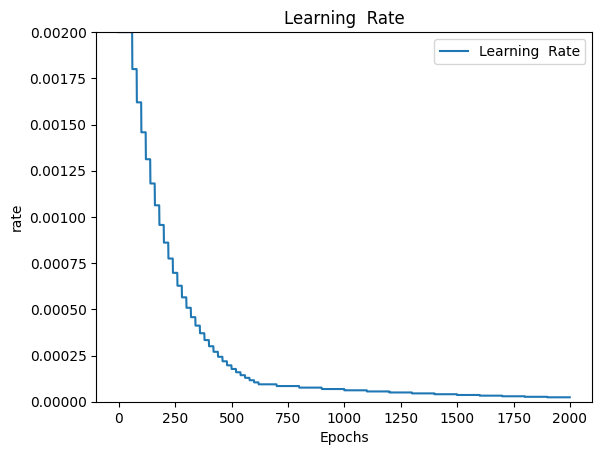

In [30]:
#!pip install scikit-learn
import matplotlib.pyplot as plt

#trainingEpoch_loss2 = torch.tensor(trainingEpoch_loss, device = 'cpu')

# Assuming you have lists `trainingEpoch_loss` and `validationEpoch_loss`
plt.plot(TrainLoss, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.ylim(0, 0.04)
plt.show()

plt.plot(ValidLoss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.plot(LearnRate, label='Learning  Rate')
plt.xlabel('Epochs')
plt.ylabel('rate')
plt.title('Learning  Rate')
plt.legend()
plt.ylim(0, LR)
plt.show()





## Task 9 : Inference


Jaccard = 0.41528546810150146 ,  Intersection = 901.0 , Union = 2172.0 , Sum = 3073.0 , Dice = 58.63976287841797


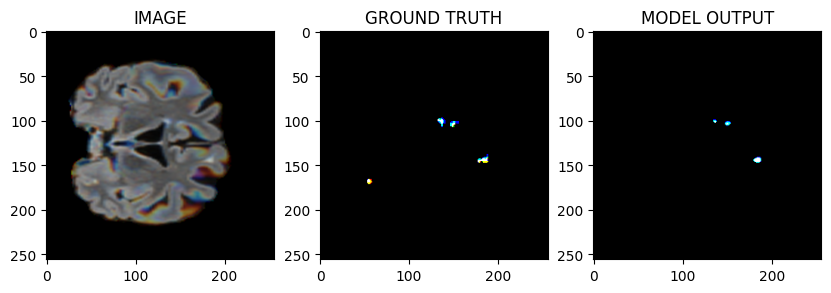

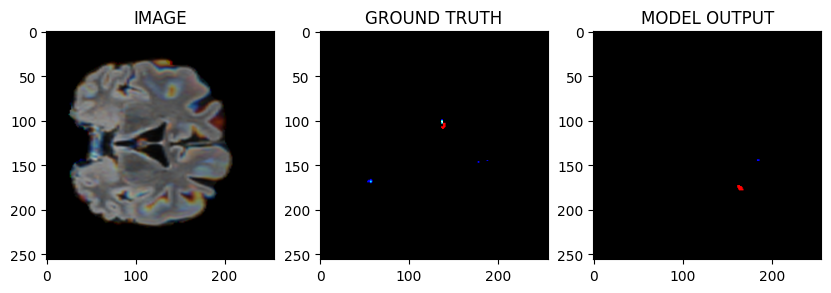

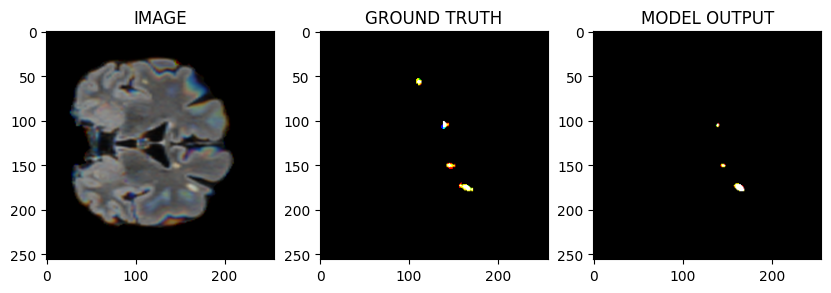

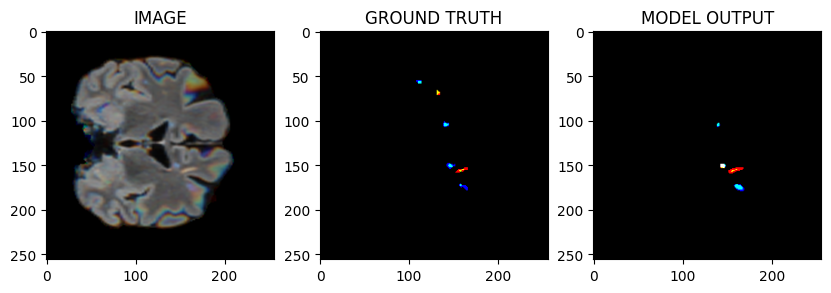

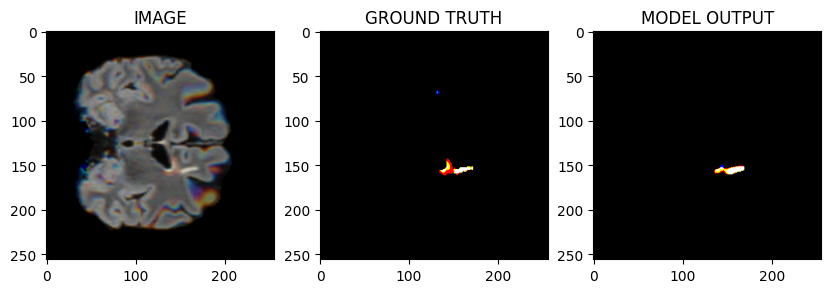

In [37]:
#idx = 689
idx = 592
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
S = BinarySum()(pred_mask, mask1)
print(f'Jaccard = {J} ,  Intersection = {I} , Union = {U} , Sum = {S} , Dice = {2*I/S*100}')

pred = pred_mask.detach().cpu().squeeze(0)
helper.show_image(image[0:3,:,:], mask[0:3,:,:], pred[0:3,:,:])
helper.show_image(image[3:6,:,:], mask[3:6,:,:], pred[3:6,:,:])
helper.show_image(image[6:9,:,:], mask[6:9,:,:], pred[6:9,:,:])
helper.show_image(image[9:12,:,:], mask[9:12,:,:], pred[9:12,:,:])
helper.show_image(image[12:15,:,:], mask[12:15,:,:], pred[12:15,:,:])


SyntaxError: invalid syntax (2482297659.py, line 1)

In [32]:
J = [0]*len(validset)
I = [0]*len(validset)
U = [0]*len(validset)
S = [0]*len(validset)
for idx in range(len(validset)):
    image, mask = validset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)
    S[idx] = BinarySum()(pred_mask, mask)

print(f'Jaccard = {sum(I)/sum(U)*100} , Dice = {2*sum(I)/sum(S)*100} ,  Intersection = {sum(I)} , Union = {sum(U)} , Sum = {sum(S)}')

J_valid = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of validation set = ', torch.mean(J_valid)*100)


Jaccard = 70.68651580810547 , Dice = 82.82612609863281 ,  Intersection = 4171378.0 , Union = 5901236.0 , Sum = 10072614.0
Jaccard Avg of validation set =  tensor(46.7968)


In [33]:
#model.load_state_dict(torch. load('Model_ep_300.pt'))

J = [0]*len(testset)
I = [0]*len(testset)
U = [0]*len(testset)
S = [0]*len(testset)
sx, su = 0, 0
for idx in range(len(testset)):
    image, mask = testset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)
    S[idx] = BinarySum()(pred_mask, mask)

print(f'Jaccard = {sum(I)/sum(U)*100} , Dice = {2*sum(I)/sum(S)*100} ,  Intersection = {sum(I)} , Union = {sum(U)} , Sum = {sum(S)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)



Jaccard = 60.13533020019531 , Dice = 75.10563659667969 ,  Intersection = 3522235.0 , Union = 5857181.0 , Sum = 9379416.0
Jaccard Avg of test set =  tensor(39.8296)
